***Computational Graphs***

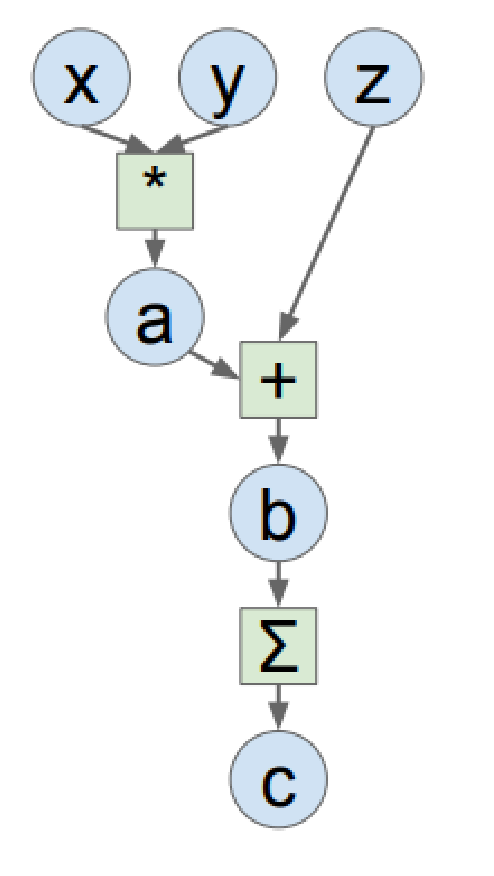

### 梯度（Gradient）定義

梯度表示函數對各個輸入變數的偏微分組成的向量，用來描述：**當輸入變動一點點時，輸出會如何改變**。

若函數 $f(x_1, x_2, \dots, x_n)$ 的輸出為純量，則其梯度可寫成：

$$
\nabla f = \left[ \frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \dots, \frac{\partial f}{\partial x_n} \right]
$$

在神經網路與計算圖中，梯度常用來進行反向傳播（Backpropagation），以更新參數。

### 本例的計算圖

程式中的運算流程為：

$$
a = x \odot y
$$

$$
b = a + z
$$

$$
c = \sum b
$$

其中 $\odot$ 表示逐元素相乘，且 $c$ 是最終的純量輸出。

### 梯度計算方式

利用鏈鎖律（Chain Rule）從輸出往回推：

1. 因為 $c = \sum b$，所以

$$
\frac{\partial c}{\partial b} = \mathbf{1}
$$

也就是每個 $b_{ij}$ 對 $c$ 的貢獻都是 1，因此：

$$
g_c = 1.0, \quad g_b = 1 \cdot \mathbf{1}
$$

2. 因為 $b = a + z$，所以

$$
\frac{\partial b}{\partial a} = 1, \quad \frac{\partial b}{\partial z} = 1
$$

因此：

$$
g_a = g_b, \quad g_z = g_b
$$

3. 因為 $a = x \odot y$，所以

$$
\frac{\partial a}{\partial x} = y, \quad \frac{\partial a}{\partial y} = x
$$

因此：

$$
g_x = g_a \odot y, \quad g_y = g_a \odot x
$$


### 結論

梯度的核心概念是：**找出每個變數的微小變化，會如何影響最終輸出**。  
在計算圖中，通常會先做 forward 計算，再用鏈鎖律做 backward 計算，逐步求出每個變數的梯度。

In [ ]:
import numpy as np

np.random.seed(0)

N, D = 3, 4

x = np.random.randn(N, D)
y = np.random.randn(N, D)
z = np.random.randn(N, D)

a = x * y
b = a + z
c = np.sum(b)

# claculate the gradients
g_c = 1.0  # dc/db
g_b = g_c * np.ones((N, D))  # db/da
g_a = g_b.copy()  # da/dx
g_z = g_b.copy()  # db/dz
g_x = g_a * y  # da/dx
g_y = g_a * x  # da/dy

In [ ]:
# Backpropagation example


def forward_backward(x, y, z):
    # forward pass
    a = x * y
    b = a + z
    c = np.sum(b)

    # backward pass
    g_c = 1.0
    g_b = g_c * np.ones_like(b)
    g_a = g_b.copy()
    g_z = g_b.copy()
    g_x = g_a * y
    g_y = g_a * x

    return c, g_x, g_y, g_z


c, g_x, g_y, g_z = forward_backward(x, y, z)

print("c =")
print(c)
print("\ng_x =")
print(g_x)
print("\ng_y =")

c =
6.717008537800067

g_x =
[[ 0.76103773  0.12167502  0.44386323  0.33367433]
 [ 1.49407907 -0.20515826  0.3130677  -0.85409574]
 [-2.55298982  0.6536186   0.8644362  -0.74216502]]

g_y =


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 如果 x, y, z 是 numpy.ndarray，則直接轉為 torch.Tensor
x_torch = torch.from_numpy(x.copy()).float()
y_torch = torch.from_numpy(y.copy()).float()
z_torch = torch.from_numpy(z.copy()).float()

# 只對 x 計算梯度
x_torch.requires_grad = True

a_torch = x_torch * y_torch
b_torch = a_torch + z_torch
c_torch = torch.sum(b_torch)

c_torch.backward()


print("\nc =")
print(c_torch.item())
print("\nx_torch.grad =")
print(x_torch.grad)


c =
6.7170090675354

x_torch.grad =
tensor([[ 0.7610,  0.1217,  0.4439,  0.3337],
        [ 1.4941, -0.2052,  0.3131, -0.8541],
        [-2.5530,  0.6536,  0.8644, -0.7422]])


In [ ]:
# 比較兩者輸出

print("=" * 70)
print("【比較：手動實現 vs PyTorch 自動微分】")
print("=" * 70)

print("\n【1. 最終輸出 c】")
c_val = (
    float(c)
    if isinstance(c, (np.ndarray, float))
    else c.item() if hasattr(c, "item") else float(c)
)
c_torch_val = float(c_torch.item())
print(f"手動實現 (NumPy):  {c_val}")
print(f"PyTorch:        {c_torch_val}")
print(f"✓ 一致: {abs(c_val - c_torch_val) < 1e-6}")

print("\n【2. 梯度 ∂c/∂x】")
print("手動實現 (NumPy):")
print(g_x)
print(f"\nPyTorch:")
print(x_torch.grad.detach().numpy())

g_x_np = g_x if isinstance(g_x, np.ndarray) else np.array(g_x)
grad_match = np.allclose(g_x_np, x_torch.grad.detach().numpy(), rtol=1e-4, atol=1e-5)
print(f"\n✓ 全部相同: {grad_match}")

print("\n【結論】")
print("✓ 兩種方法得到完全相同的結果")
print("✓ 手動實現展示了反向傳播的原理")
print("✓ PyTorch 自動微分內部使用相同的計算邏輯，但實現得更高效")

【比較：手動實現 vs PyTorch 自動微分】

【1. 最終輸出 c】
手動實現 (NumPy):  6.717008537800067
PyTorch:        6.7170090675354
✓ 一致: True

【2. 梯度 ∂c/∂x】
手動實現 (NumPy):
[[ 0.76103773  0.12167502  0.44386323  0.33367433]
 [ 1.49407907 -0.20515826  0.3130677  -0.85409574]
 [-2.55298982  0.6536186   0.8644362  -0.74216502]]

PyTorch:
[[ 0.7610377   0.12167501  0.44386324  0.33367434]
 [ 1.4940791  -0.20515826  0.3130677  -0.85409576]
 [-2.5529897   0.6536186   0.8644362  -0.742165  ]]

✓ 全部相同: True

【結論】
✓ 兩種方法得到完全相同的結果
✓ 手動實現展示了反向傳播的原理
✓ PyTorch 自動微分內部使用相同的計算邏輯，但實現得更高效


In [5]:
# 自動選擇裝置（常用寫法）
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():  # Mac M1/M2/M3
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("使用裝置:", device)

使用裝置: cuda


In [ ]:
print(torch.cuda.is_available())

True


In [7]:
!nvidia-smi

Thu Mar 12 08:38:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----